# Overview

This notebook will cluster neurons with and without including neuronal IEGs in the HVG list.

The IEG list I will use is defined in Tyssowski et al. 2018 by the "rapid PRGs" that are upregulated in the 1st hour following brief depolarization (i.e., the column on the right)

![Screenshot 2024-01-19 at 12.25.54 PM.png](<attachment:Screenshot 2024-01-19 at 12.25.54 PM.png>)

### outline of notebook

0. imports, initialization, and IEG list
1. load data pre-HVG selection
2. remove IEGs from data
3. perform feature selection
4. regress out covariates
5. scale data
6. run PCA
7. make neighborhood graph
8. louvain clustering
9. map to allen types
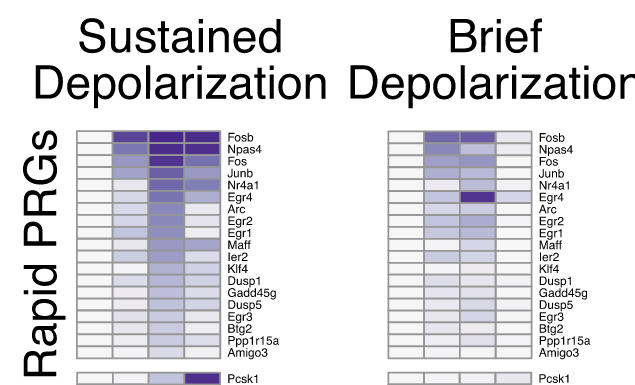

## imports, initialization, IEG list

In [1]:
import os
import clusta
import warnings
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'avenir'
plt.rcParams['figure.dpi'] = 150

In [2]:
data_path = clusta.get_data_path('combined')

In [3]:
IEG_list = [
    'Fosb',
    'Npas4',
    'Fos',
    'Junb',
    'Nr4a1',
    'Egr4',
    'Arc',
    'Egr2',
    'Egr1',
    'Maff',
    'Ier2',
    'Klf4',
    'Dusp1',
    'Dusp5',
    'Egr3',
    'Btg2',
    'Ppp1r15a',
    'Amigo3',
]

IEG_list.sort()
IEG_list

['Amigo3',
 'Arc',
 'Btg2',
 'Dusp1',
 'Dusp5',
 'Egr1',
 'Egr2',
 'Egr3',
 'Egr4',
 'Fos',
 'Fosb',
 'Ier2',
 'Junb',
 'Klf4',
 'Maff',
 'Npas4',
 'Nr4a1',
 'Ppp1r15a']

## load data pre-HVG selection

I want to use the adata object saved relatively early in the preprocessing pipeline, before genes were excluded based on low dispersion. This is just in case any IEGs were removed during feature selection--unlikely, but important.

After loading this in, I need information about what Allen cell type these were eventually assigned to *after* preprocessing. In this case, I will use the subclass taxon that captures CA1/Pro-subiculum neurons. All other cells will be excluded for now.

I will remove all IEGs and then proceed with the rest of the preprocessing pipeline.

In [4]:
adata_clustered = sc.read_h5ad(os.path.join(data_path, 'adata.h5ad'))  # has Allen taxonomy metadata
adata = sc.read_h5ad(os.path.join(data_path, 'adata_preFeatSelection.h5ad')) # has all genes before clustering

# merge metadata from both adata objects
adata.obs['subclass_label'] = adata.obs.join(adata_clustered.obs['subclass_label'])['subclass_label']

## remove IEGs from data

In [5]:
# check that all IEGs are in the data
for gene in IEG_list:
    if gene not in adata.var_names:
        print(f'{gene} not in adata.var_names')

# remove IEGs from adata
adata = adata[:, ~adata.var_names.isin(IEG_list)]

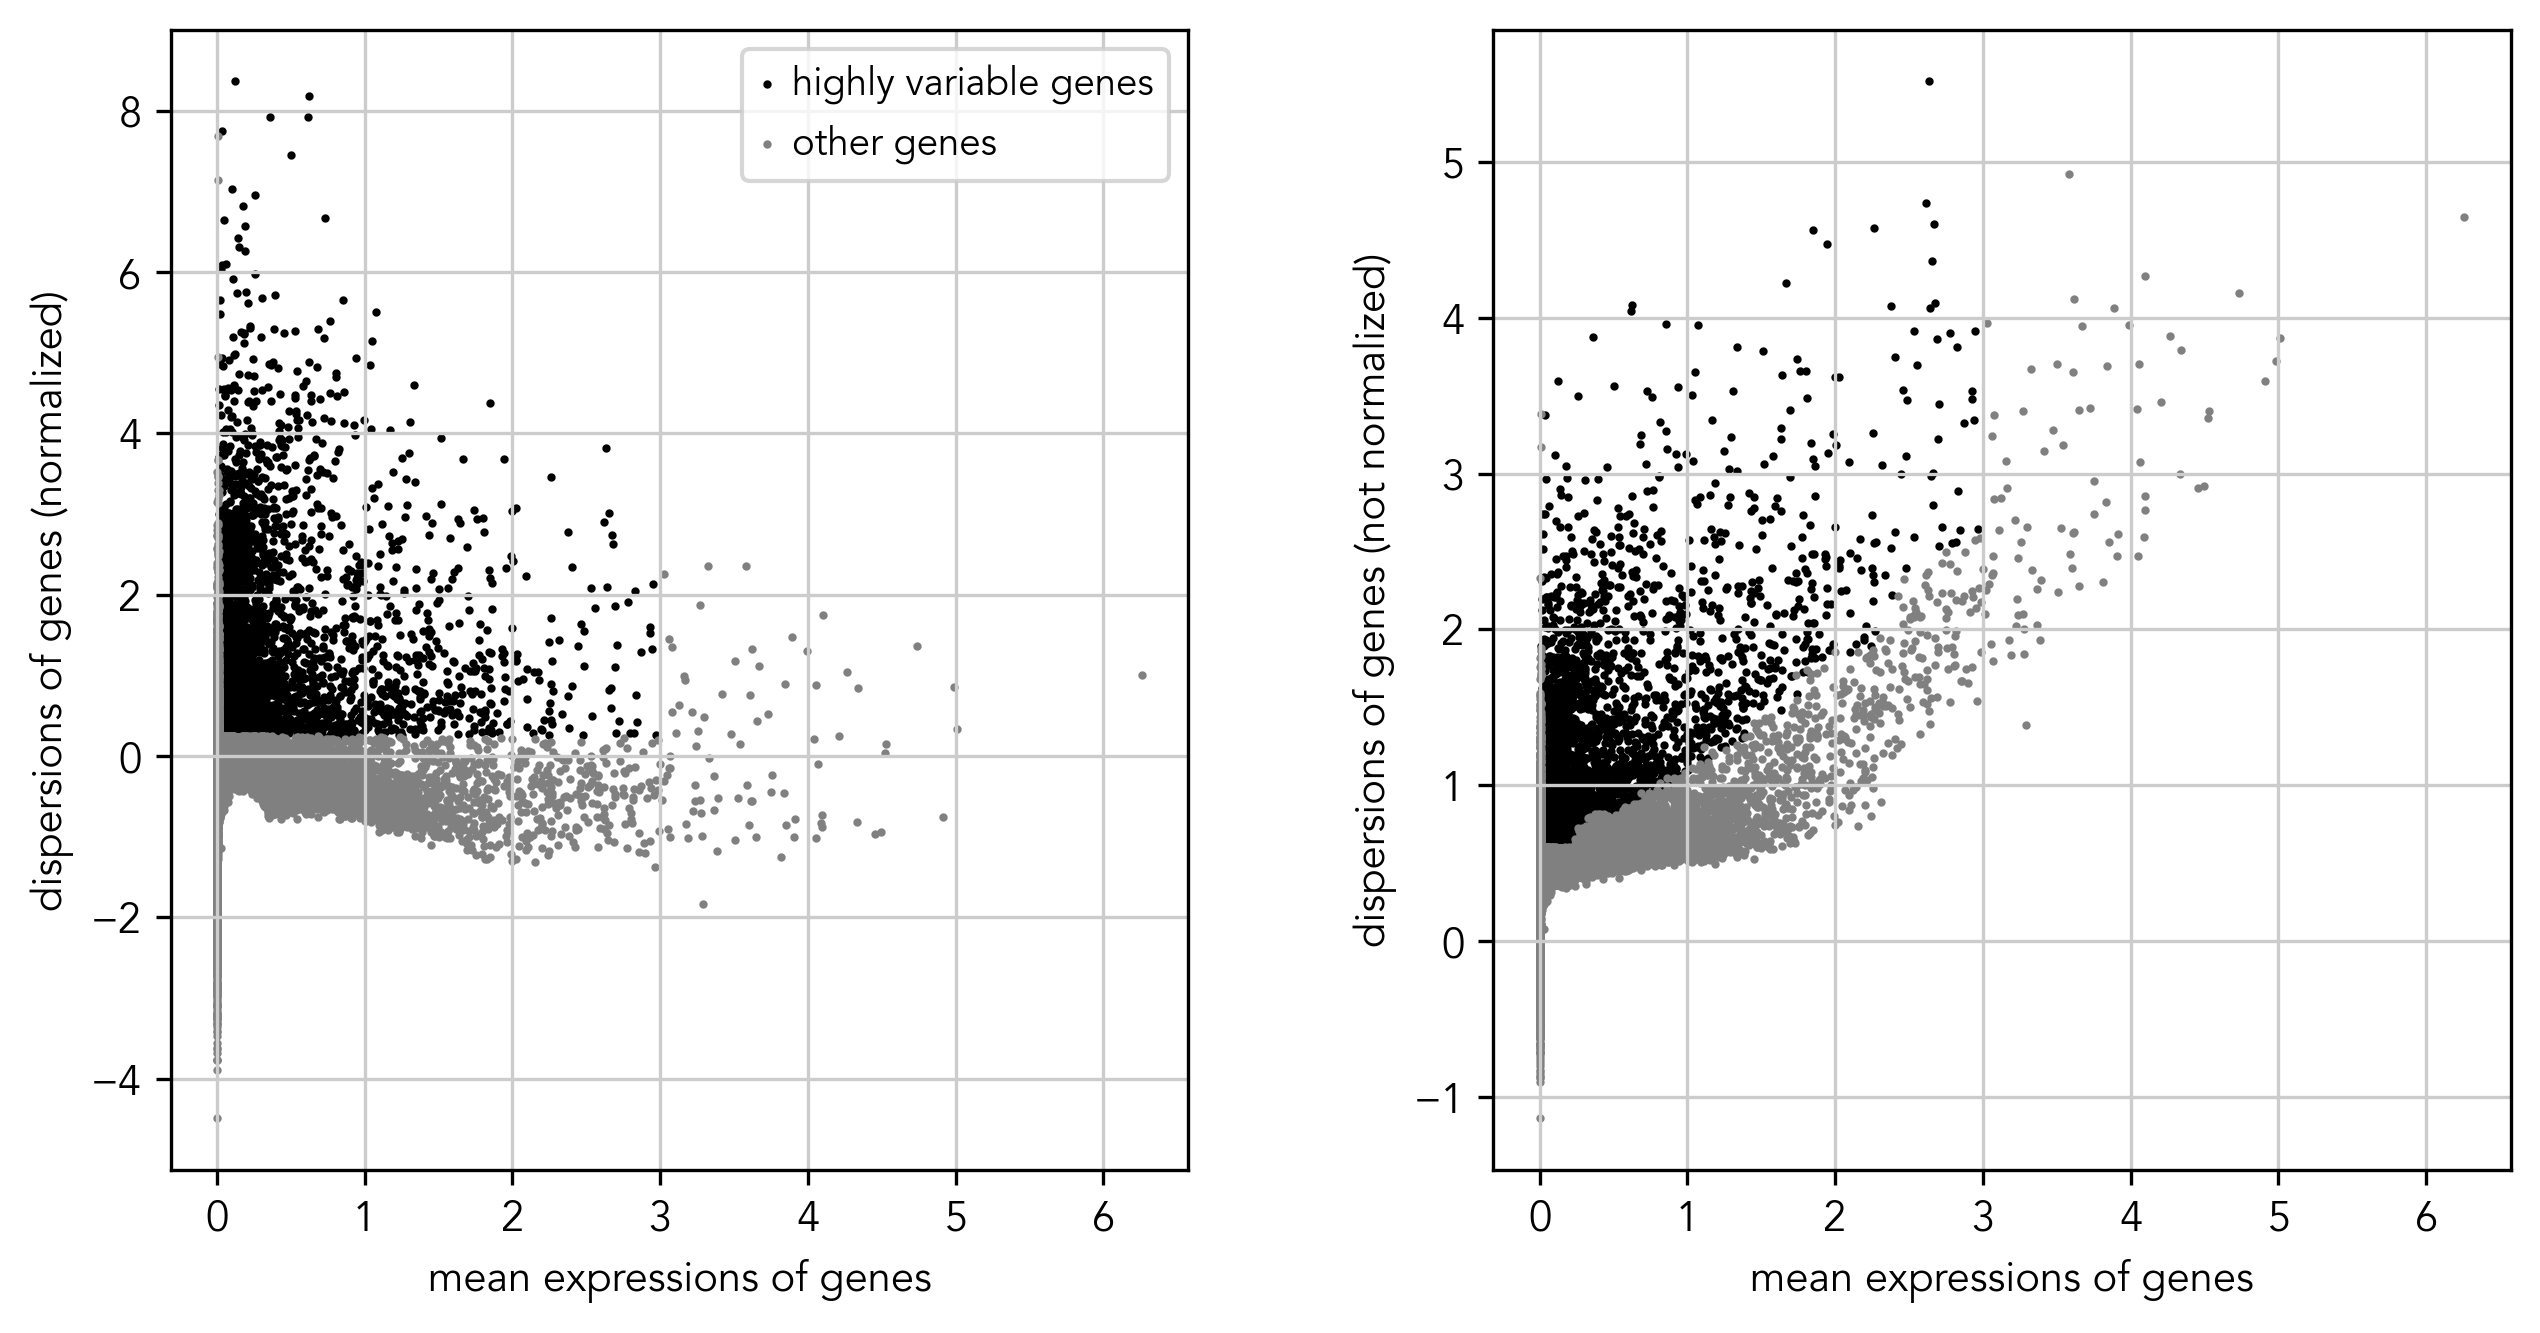

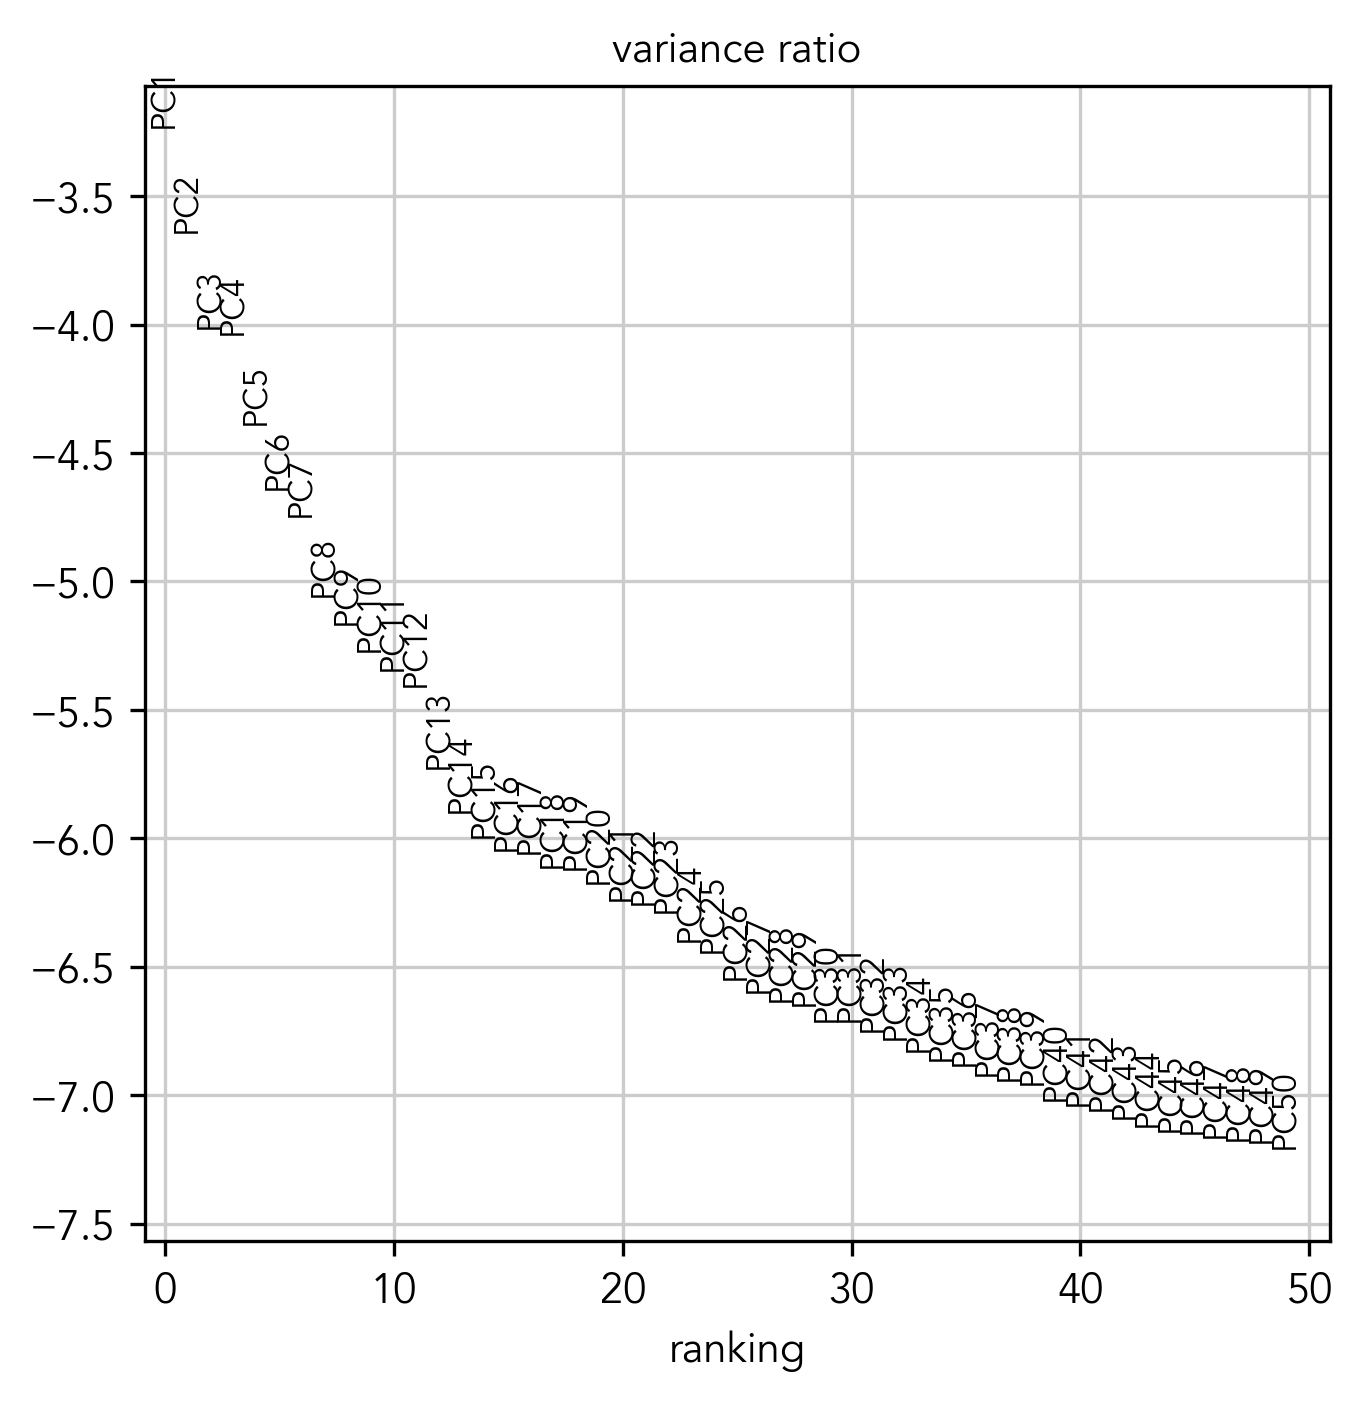

In [6]:
adata = clusta.select_hvgs(adata)

adata = clusta.regress_out_covariates(adata, covariates=['total_counts'])

adata = clusta.scale_data(adata)

adata = clusta.run_pca(adata, n_pcs=50)

In [7]:
num_PCs_to_use = 41

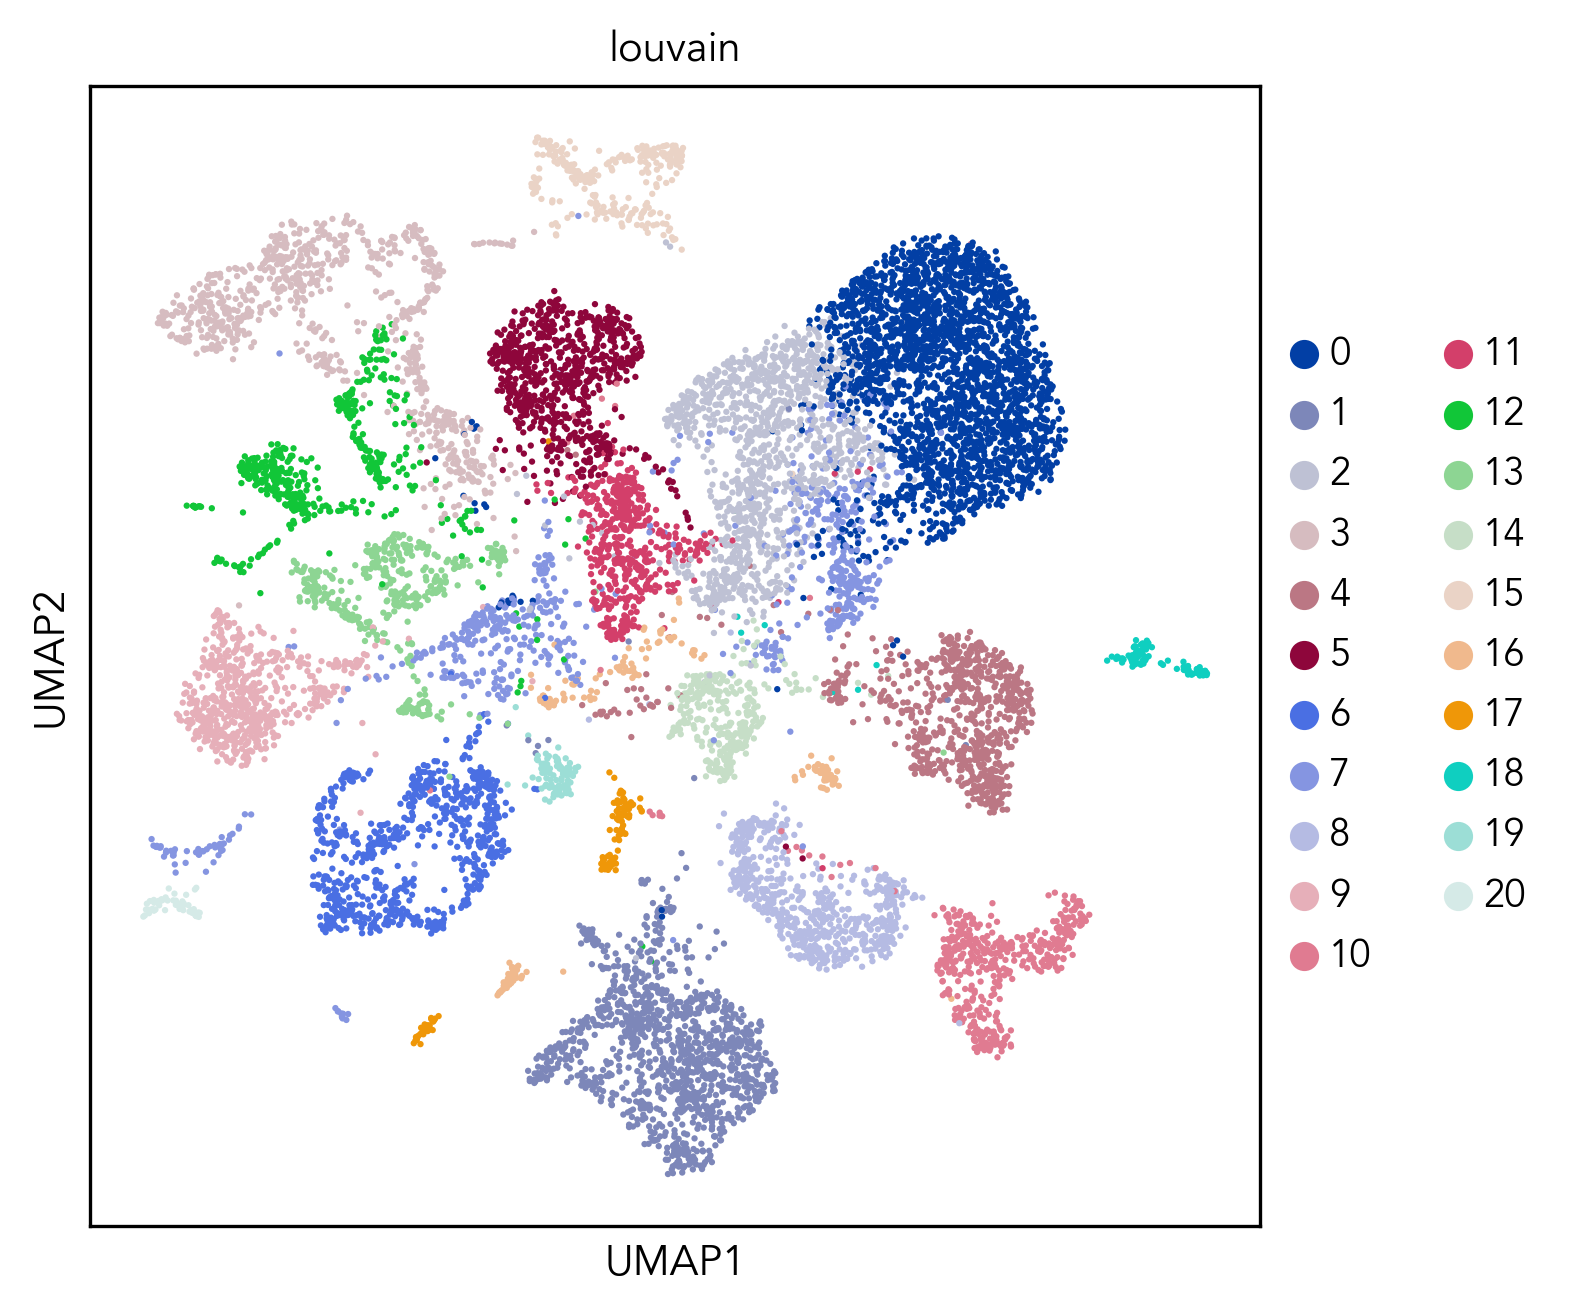

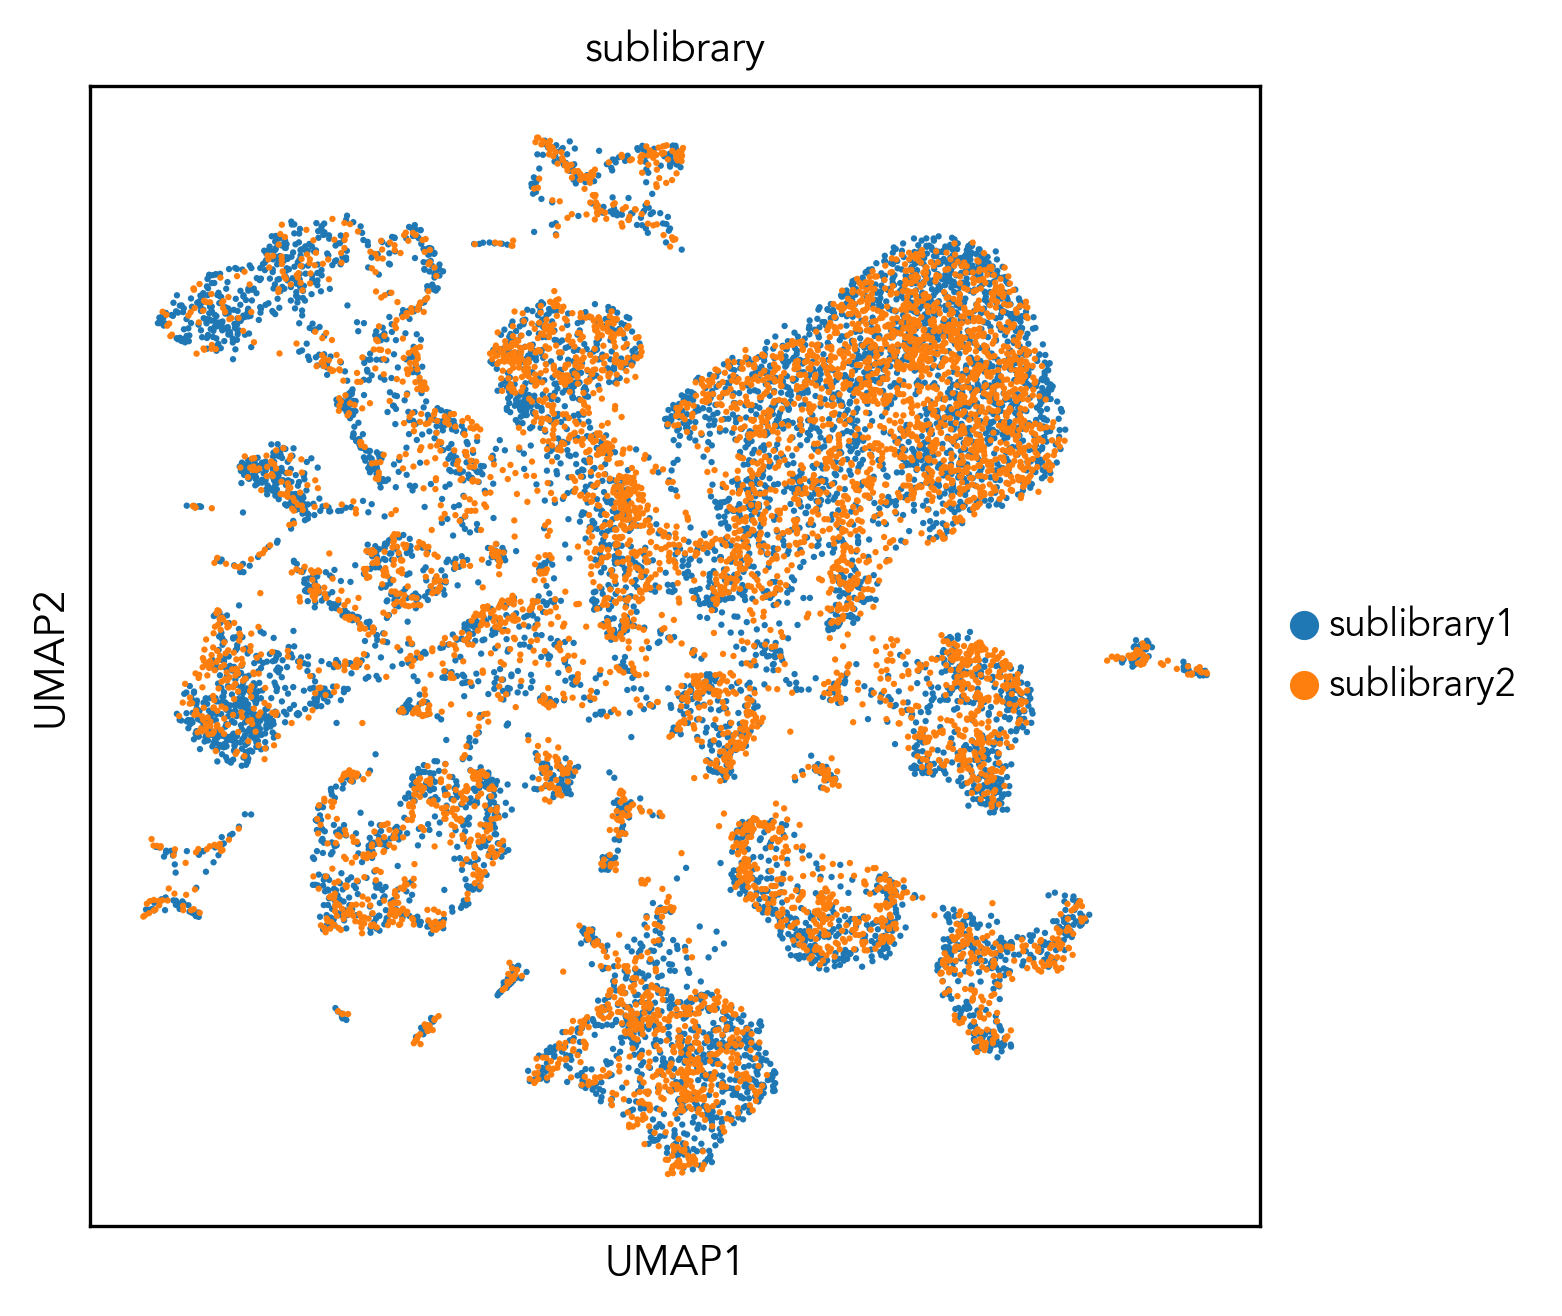

In [8]:
adata = clusta.make_neighborhood_graph(adata, num_PCs_to_use=num_PCs_to_use)

adata = clusta.louvain_cluster(adata)

clusta.make_adata_lean(adata, 'adata_lean_no_IEGs.h5ad')

~ run MapMyCells in browser ~

In [9]:
csv_path = 'adata_lean_no_IEGs_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1705709840936/adata_lean_no_IEGs_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1705709840936.csv'

# need to rename old subclass_label for merge_allen_celltypes to work
adata.obs['subclass_label_old'] = adata.obs['subclass_label']
adata.obs.drop(columns=['subclass_label'], inplace=True)

adata = clusta.merge_allen_celltypes(adata, csv_path)

adata.obs

ValueError: allen_csv_path does not exist in /Volumes/jack/seq/analysis/combined/0_all-sample/DGE_filtered/

In [ ]:
import clusta
adata = clusta.get_taxonomy_cmap(adata)

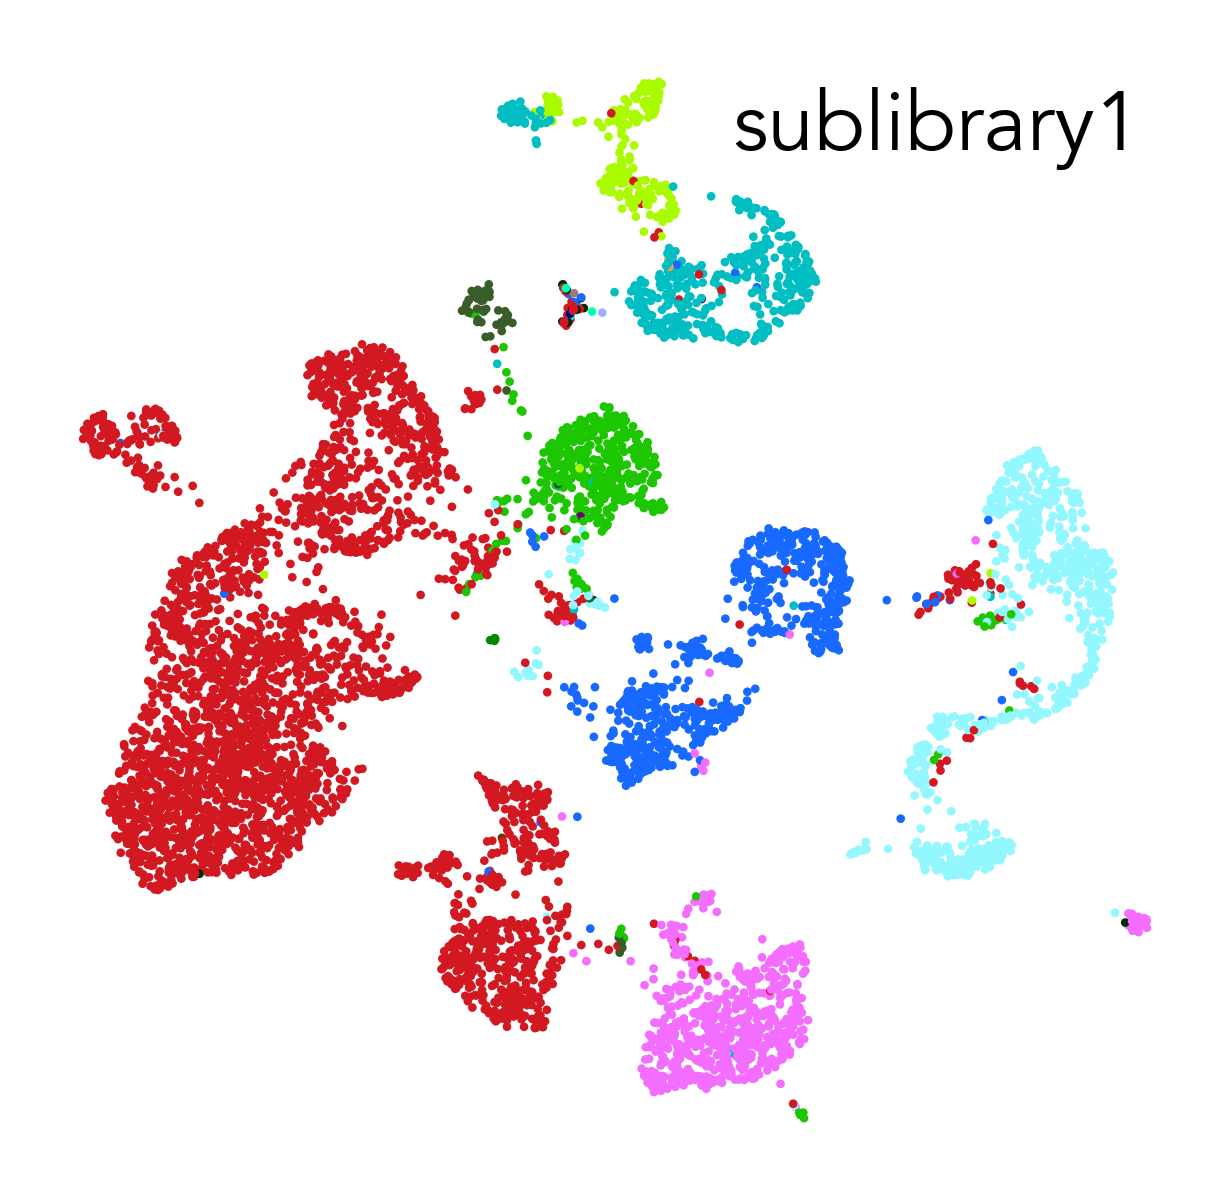

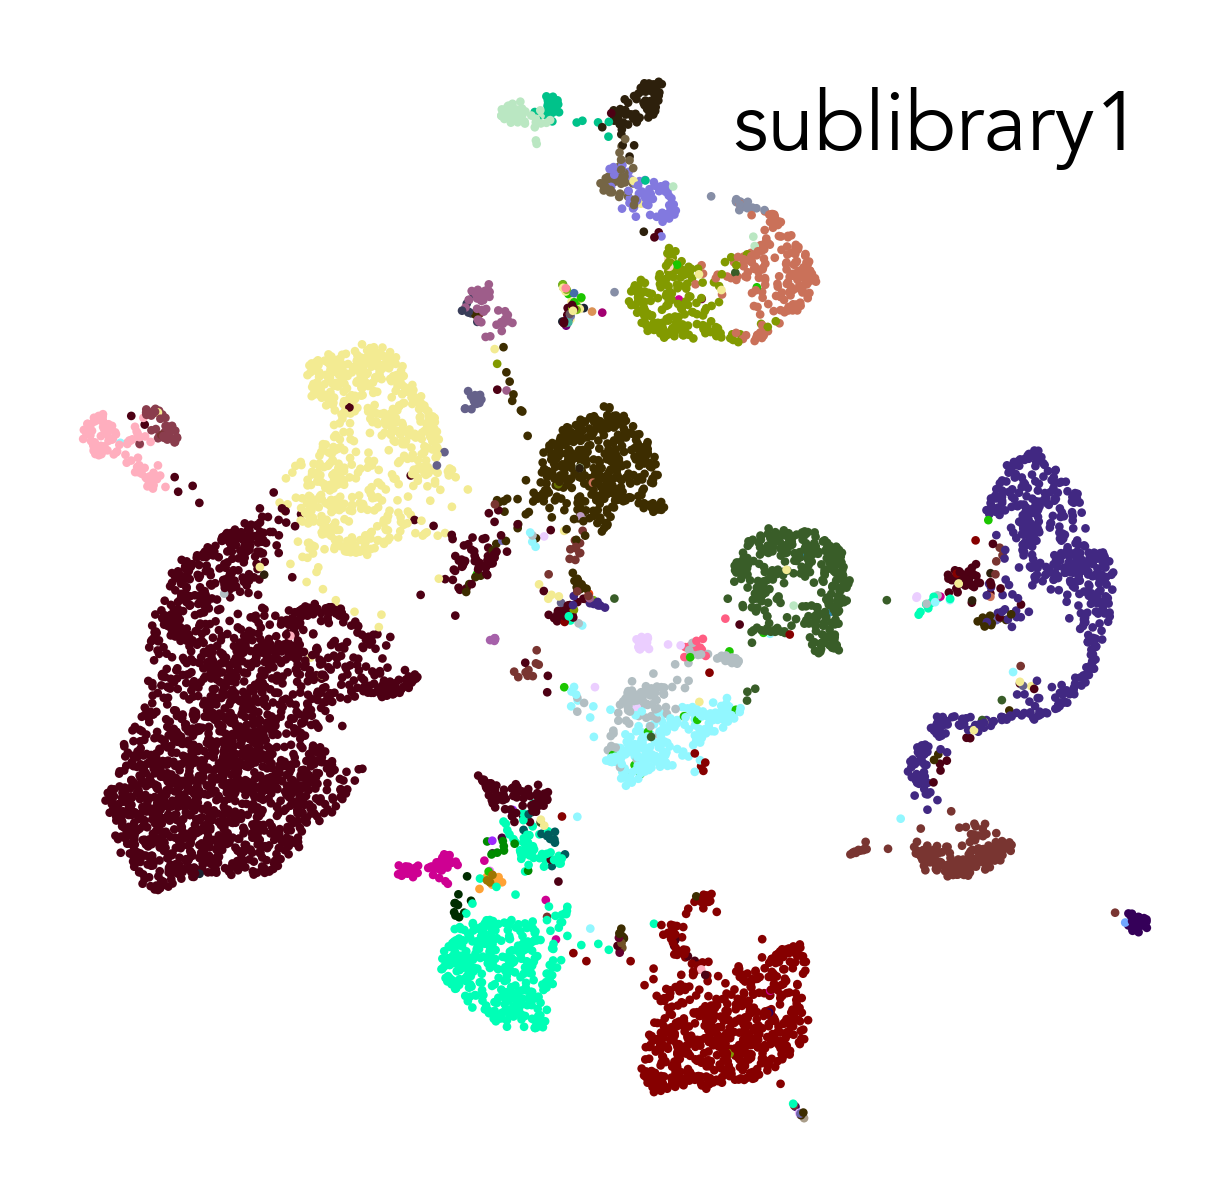

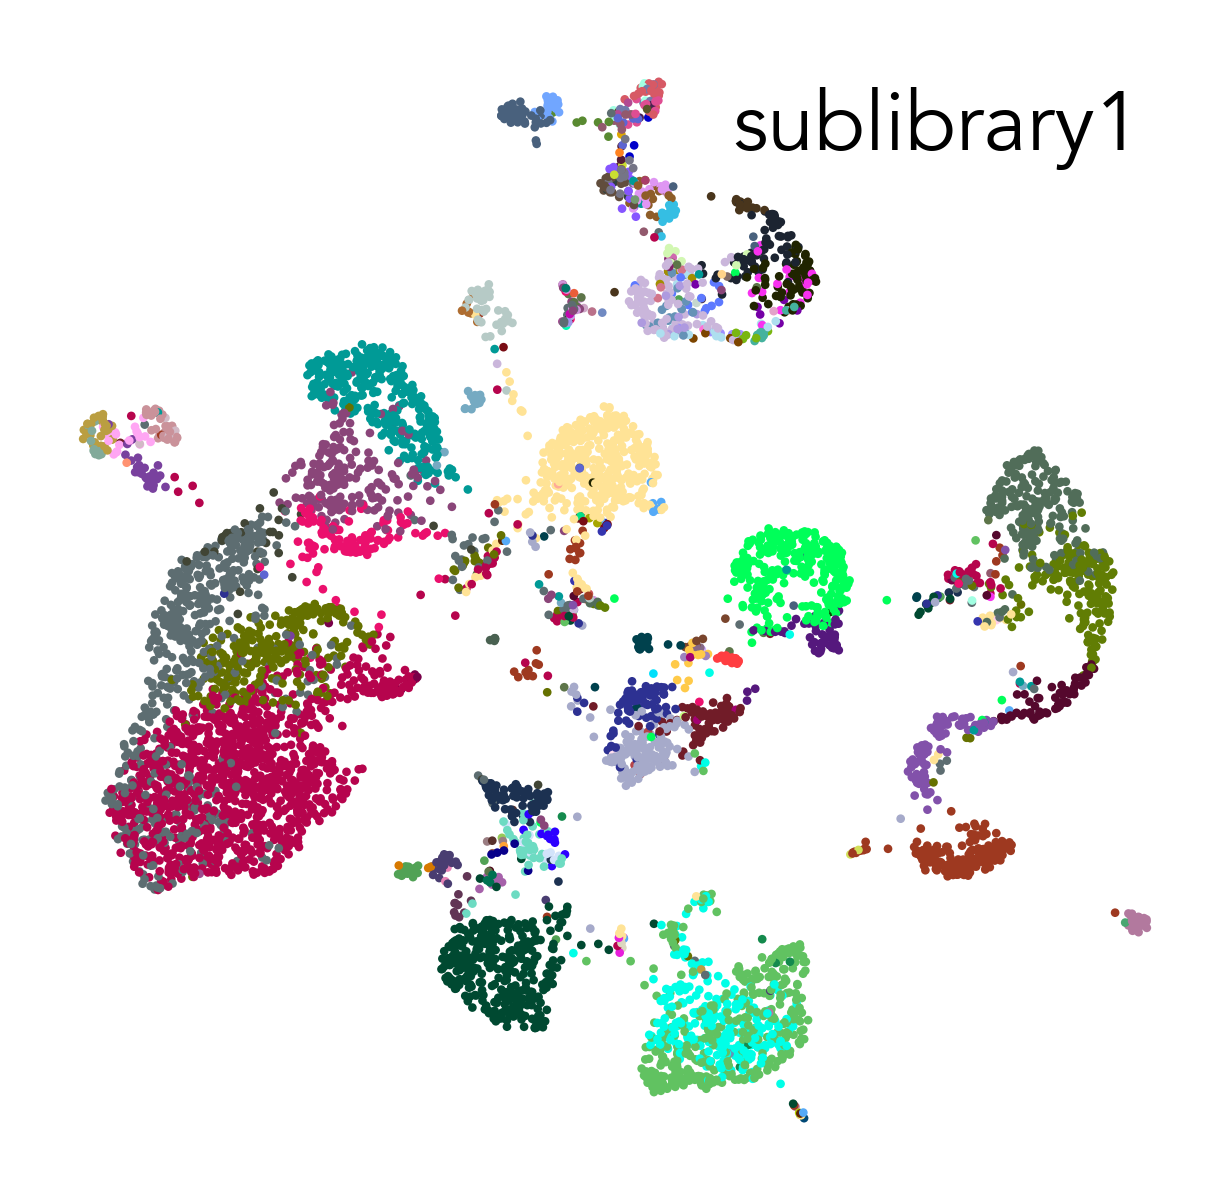

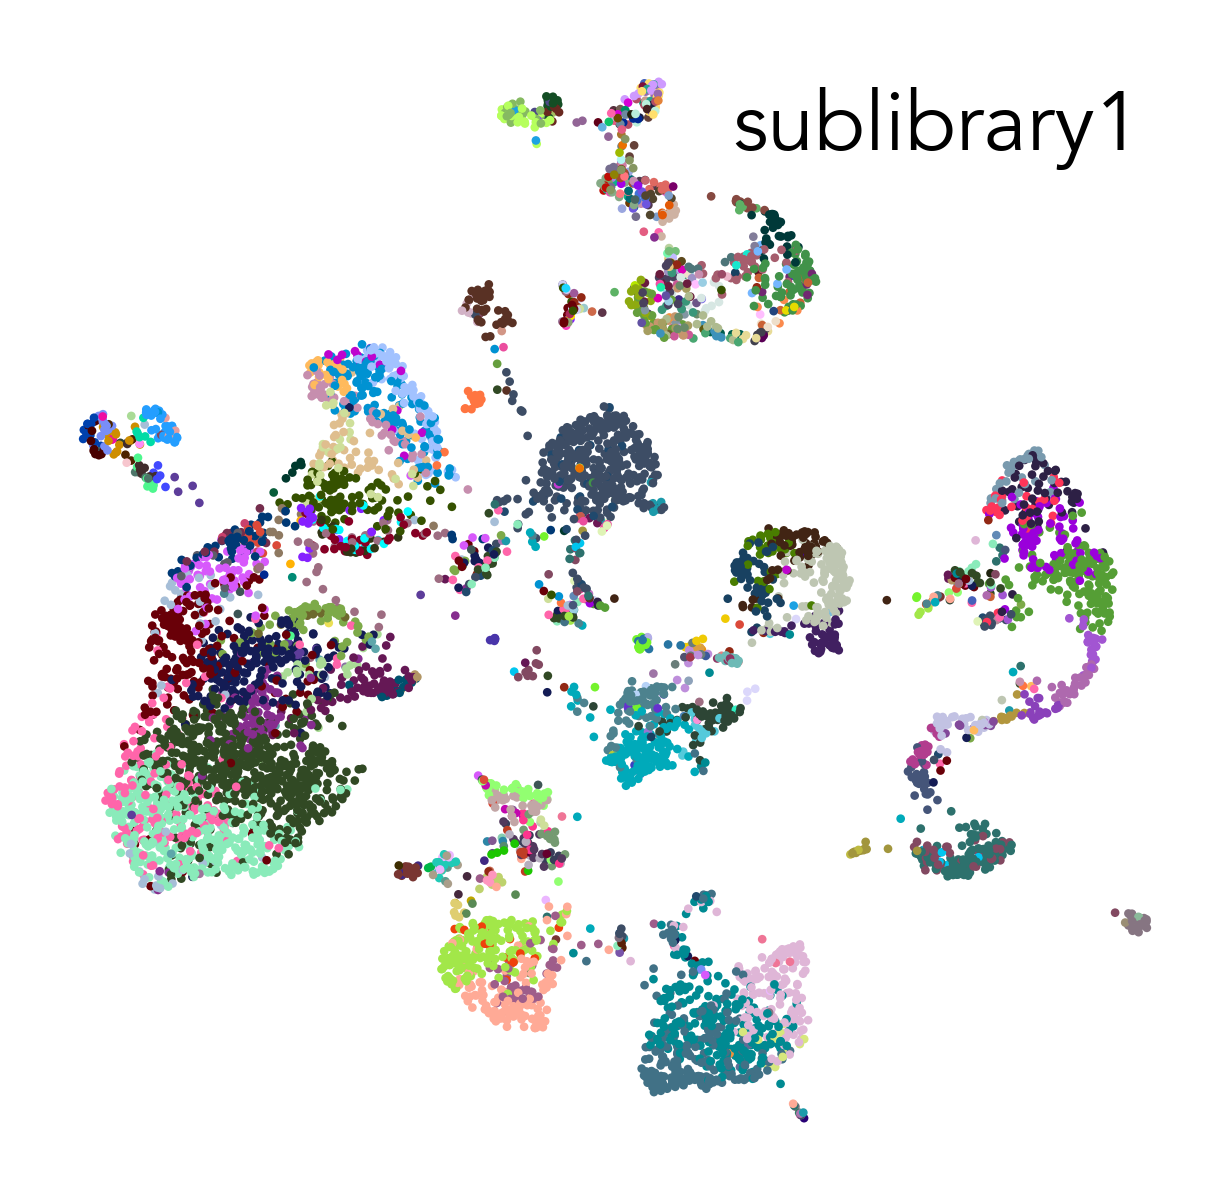

In [ ]:
labs = ['class_name', 'subclass_name', 'supertype_name', 'cluster_name']
for lab in labs:
    sc.pl.umap(adata, color=[lab], show=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().set_xlabel('')
    plt.gca().set_ylabel('')
    plt.gca().set_title('')
    plt.gca().get_legend().remove()

    # annotate gca in the top right with lab
    plt.gca().annotate(adata.uns['sublibrary'], xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top', fontweight='bold', fontsize=20)

# secondary analysis

Awesome. So we have some clustering with and without IEGs.

I want to compare the UMAPs of just subclass 16 clustered with and without IEGs.

To do this, I'll need to load in the normal adata object as well as the no-IEG object. And then I'll cut all the classes that aren't subclass 16 from each object and plot by cluster.

In [ ]:
adata_yes_IEGs = sc.read_h5ad(os.path.join(data_path, 'adata.h5ad'))
adata_no_IEGs = adata

In [ ]:
# remove all cells that don't correspond to subclass_name == '016 CA1-ProS Glut'
adata_yes_IEGs = adata_yes_IEGs[adata_yes_IEGs.obs['subclass_name'] == '016 CA1-ProS Glut', :]
adata_no_IEGs = adata_no_IEGs[adata_no_IEGs.obs['subclass_name'] == '016 CA1-ProS Glut', :]

# map clusters to consistent colors
adata_yes_IEGs = clusta.get_taxonomy_cmap(adata_yes_IEGs)
adata_yes_IEGs.obs['cluster_color'] = adata_yes_IEGs.obs['cluster_name'].map(adata_yes_IEGs.uns['cluster_colorDict'])

adata_no_IEGs = clusta.get_taxonomy_cmap(adata_no_IEGs)
adata_no_IEGs.obs['cluster_color'] = adata_no_IEGs.obs['cluster_name'].map(adata_no_IEGs.uns['cluster_colorDict'])

Text(0.5, 1.0, 'EXCLUDING IEGs')

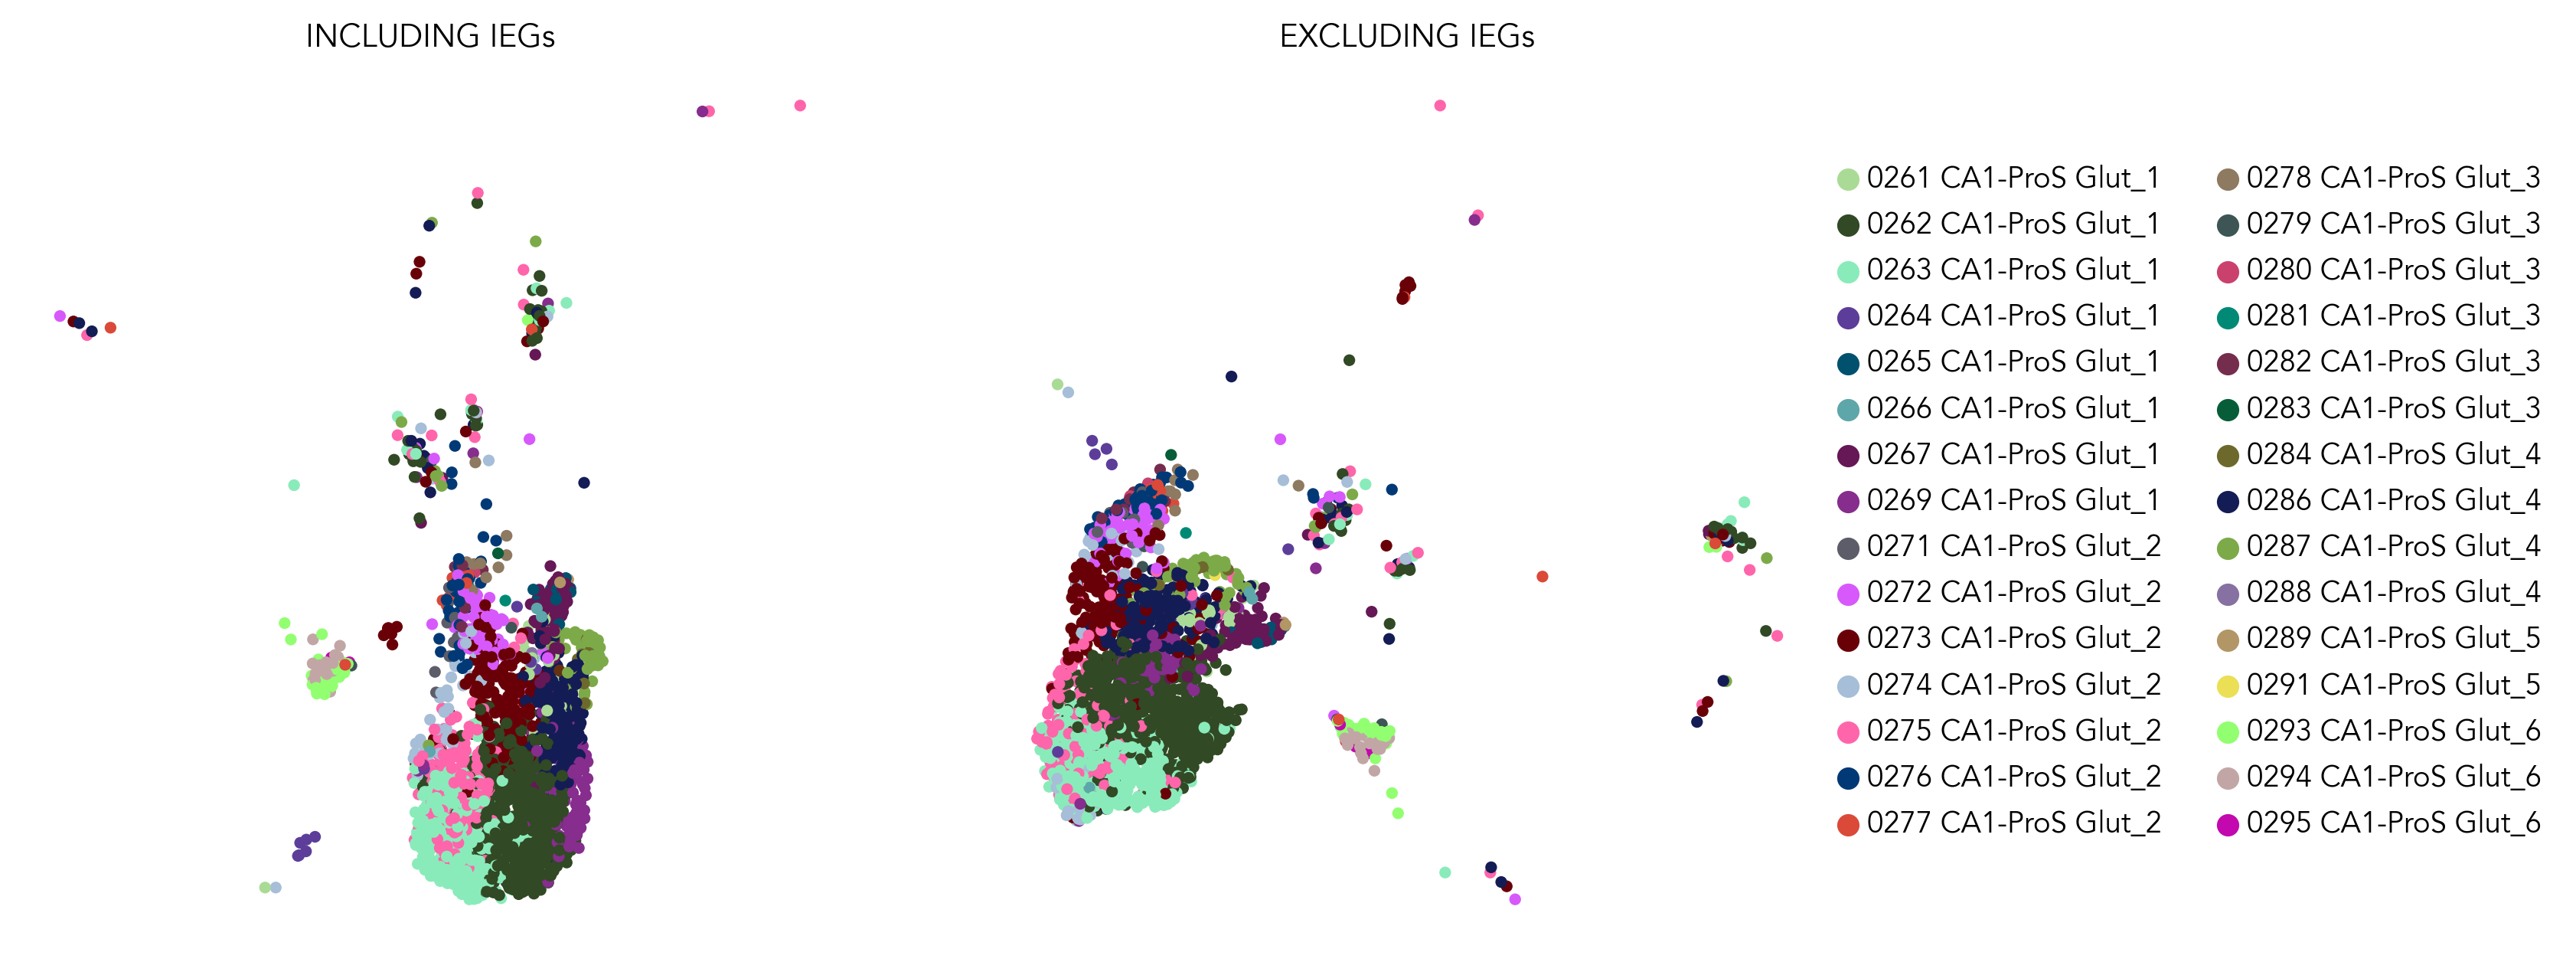

In [ ]:
# plot UMAPs for both objects on the same figure
plt.figure(figsize=(10, 5))

plt.subplot(121)
sc.pl.umap(adata_yes_IEGs, ax=plt.gca(), color=[lab], show=False, frameon=False)
plt.gca().set_xlabel('')
plt.gca().set_ylabel('')
plt.gca().set_title('INCLUDING IEGs')
plt.gca().get_legend().remove()

plt.subplot(122)
sc.pl.umap(adata_no_IEGs, ax=plt.gca(), color=[lab], show=False, frameon=False)
plt.gca().set_xlabel('')
plt.gca().set_ylabel('')
plt.gca().set_title('EXCLUDING IEGs')
# plt.gca().get_legend().remove()

In [ ]:
import plotly.express as px

# make a countplot with plotly
fig = px.histogram(adata_yes_IEGs.obs, x='cluster_name', color='cluster_name', color_discrete_map=adata_yes_IEGs.uns['cluster_colorDict'], title='INCLUDING IEGs')
fig.update_xaxes(categoryorder='total descending')
fig.update_xaxes(tickangle=300)
fig.update_yaxes(range=[0, 700])
fig.show()

fig = px.histogram(adata_no_IEGs.obs, x='cluster_name', color='cluster_name', color_discrete_map=adata_no_IEGs.uns['cluster_colorDict'], title='EXCLUDING IEGs')
fig.update_xaxes(categoryorder='total descending')
fig.update_xaxes(tickangle=300)
fig.update_yaxes(range=[0, 700])
fig.show()

In [ ]:
adata_yes_IEGs.obs['cluster_name'].value_counts()

cluster_name
0262 CA1-ProS Glut_1    668
0263 CA1-ProS Glut_1    345
0273 CA1-ProS Glut_2    220
0286 CA1-ProS Glut_4    210
0275 CA1-ProS Glut_2    172
0269 CA1-ProS Glut_1     87
0272 CA1-ProS Glut_2     82
0287 CA1-ProS Glut_4     70
0267 CA1-ProS Glut_1     67
0276 CA1-ProS Glut_2     49
0274 CA1-ProS Glut_2     48
0293 CA1-ProS Glut_6     40
0294 CA1-ProS Glut_6     30
0261 CA1-ProS Glut_1     21
0265 CA1-ProS Glut_1     18
0277 CA1-ProS Glut_2     14
0264 CA1-ProS Glut_1     12
0282 CA1-ProS Glut_3     11
0271 CA1-ProS Glut_2     10
0278 CA1-ProS Glut_3      9
0284 CA1-ProS Glut_4      7
0289 CA1-ProS Glut_5      7
0279 CA1-ProS Glut_3      5
0266 CA1-ProS Glut_1      5
0280 CA1-ProS Glut_3      4
0295 CA1-ProS Glut_6      4
0281 CA1-ProS Glut_3      2
0283 CA1-ProS Glut_3      1
0270 CA1-ProS Glut_1      1
0288 CA1-ProS Glut_4      1
0291 CA1-ProS Glut_5      1
Name: count, dtype: int64

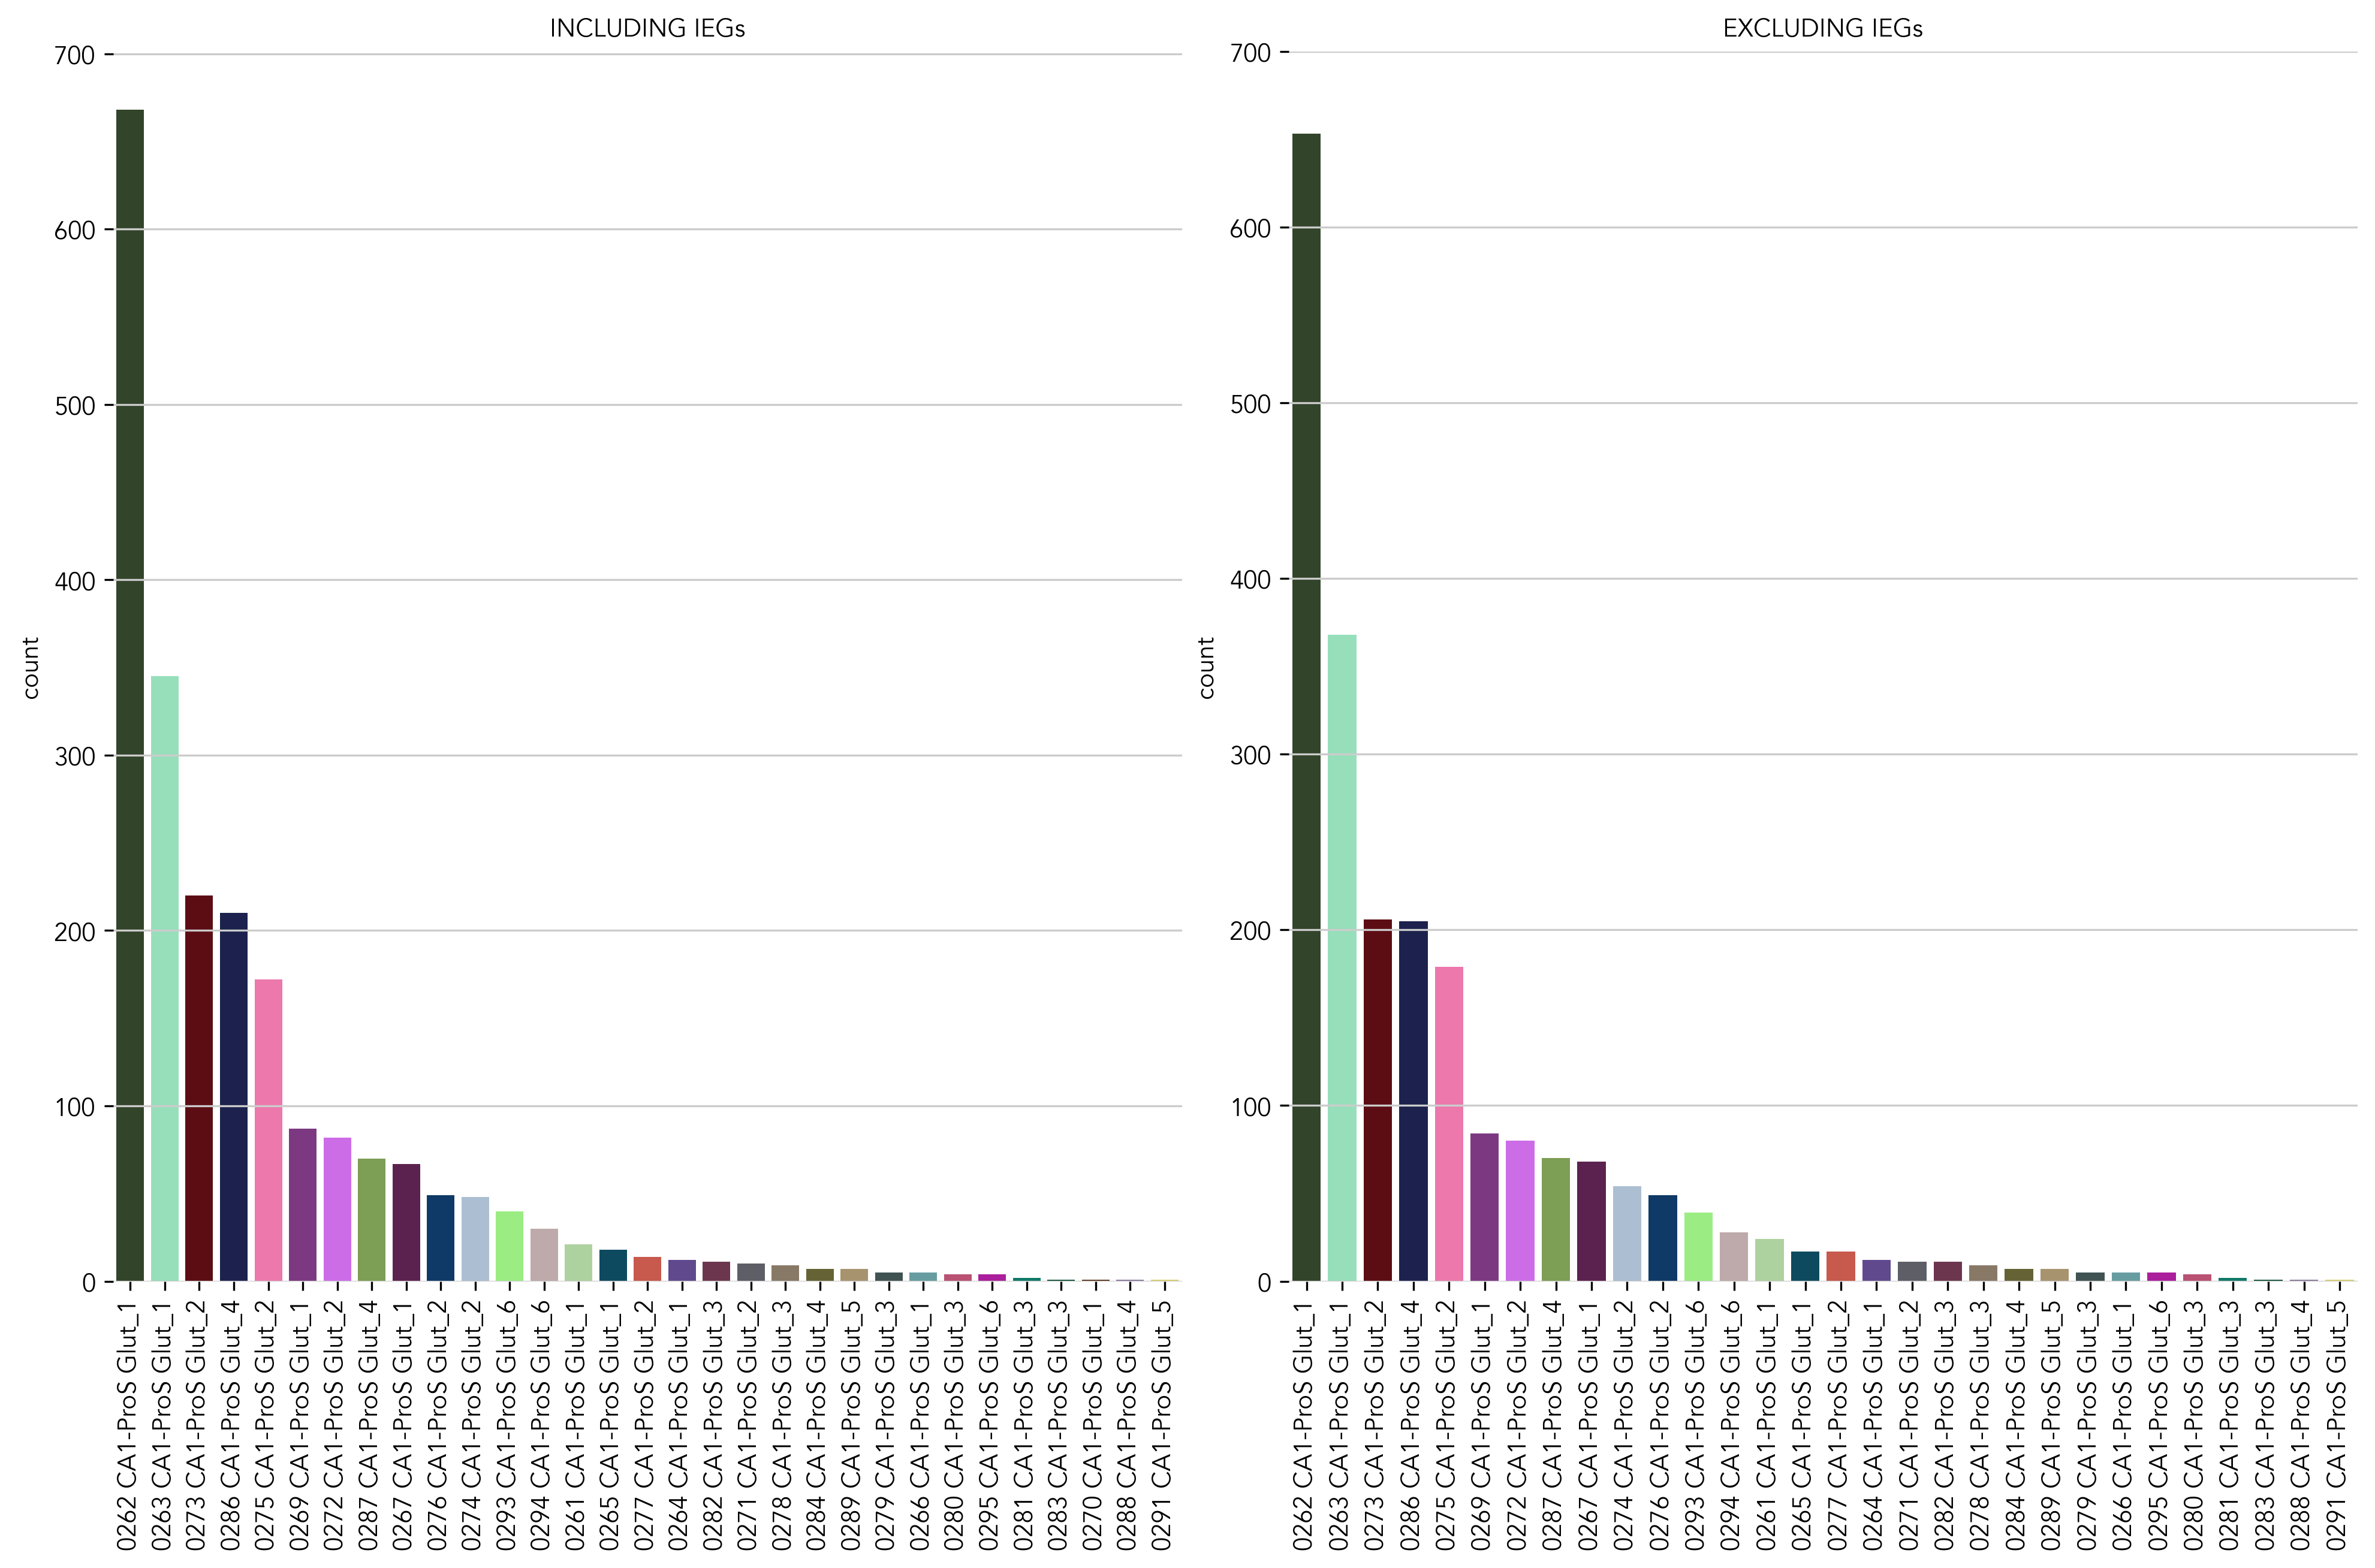

In [ ]:
plt.figure(figsize=(16,9))

plt.subplot(121)
sns.countplot(x='cluster_name', data=adata_yes_IEGs.obs, order=adata_yes_IEGs.obs['cluster_name'].value_counts().index, hue='cluster_name', palette=adata_yes_IEGs.uns['cluster_name_colors'])
plt.gca().tick_params(axis='x', rotation=90)
plt.gca().set_title('INCLUDING IEGs')
plt.gca().set_xlabel('')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().set_frame_on(False)

plt.subplot(122)
sns.countplot(x='cluster_name', data=adata_no_IEGs.obs, order=adata_no_IEGs.obs['cluster_name'].value_counts().index, hue='cluster_name', palette=adata_no_IEGs.uns['cluster_name_colors'])
plt.gca().tick_params(axis='x', rotation=90)
plt.gca().set_title('EXCLUDING IEGs')
plt.gca().set_xlabel('')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().set_ylim((0, 700))
plt.gca().set_frame_on(False)

plt.subplots_adjust(wspace=0.1)



Very interesting... cluster 269 (dark purple on the right of the cluster when IEGs are included) seems to disperse into the middle. I want to make a Sankey diagram of this

In [ ]:
import plotly.graph_objects as go
import kaleido
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming adata_yes_IEGs.obs and adata_no_IEGs.obs are DataFrames with relevant data

# Create a DataFrame for the Sankey diagram
sankey_data = pd.DataFrame({
    'source': adata_yes_IEGs.obs['cluster_name'],
    'target': adata_no_IEGs.obs['cluster_name'],
    'value': 1  # or use the actual counts if available
})

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=adata_yes_IEGs.obs['cluster_name'].unique().tolist() +
              adata_no_IEGs.obs['cluster_name'].unique().tolist()
    ),
    link=dict(
        source=sankey_data['source'].astype(str),
        target=sankey_data['target'].astype(str),
        value=sankey_data['value']
    )
)])

# Update layout for a better display
fig.update_layout(title_text="Sankey Diagram",
                  font_size=10,
                  autosize=False,
                  width=800,
                  height=400)

# Show the plot
fig.show()

<Axes: xlabel='count', ylabel='Count'>

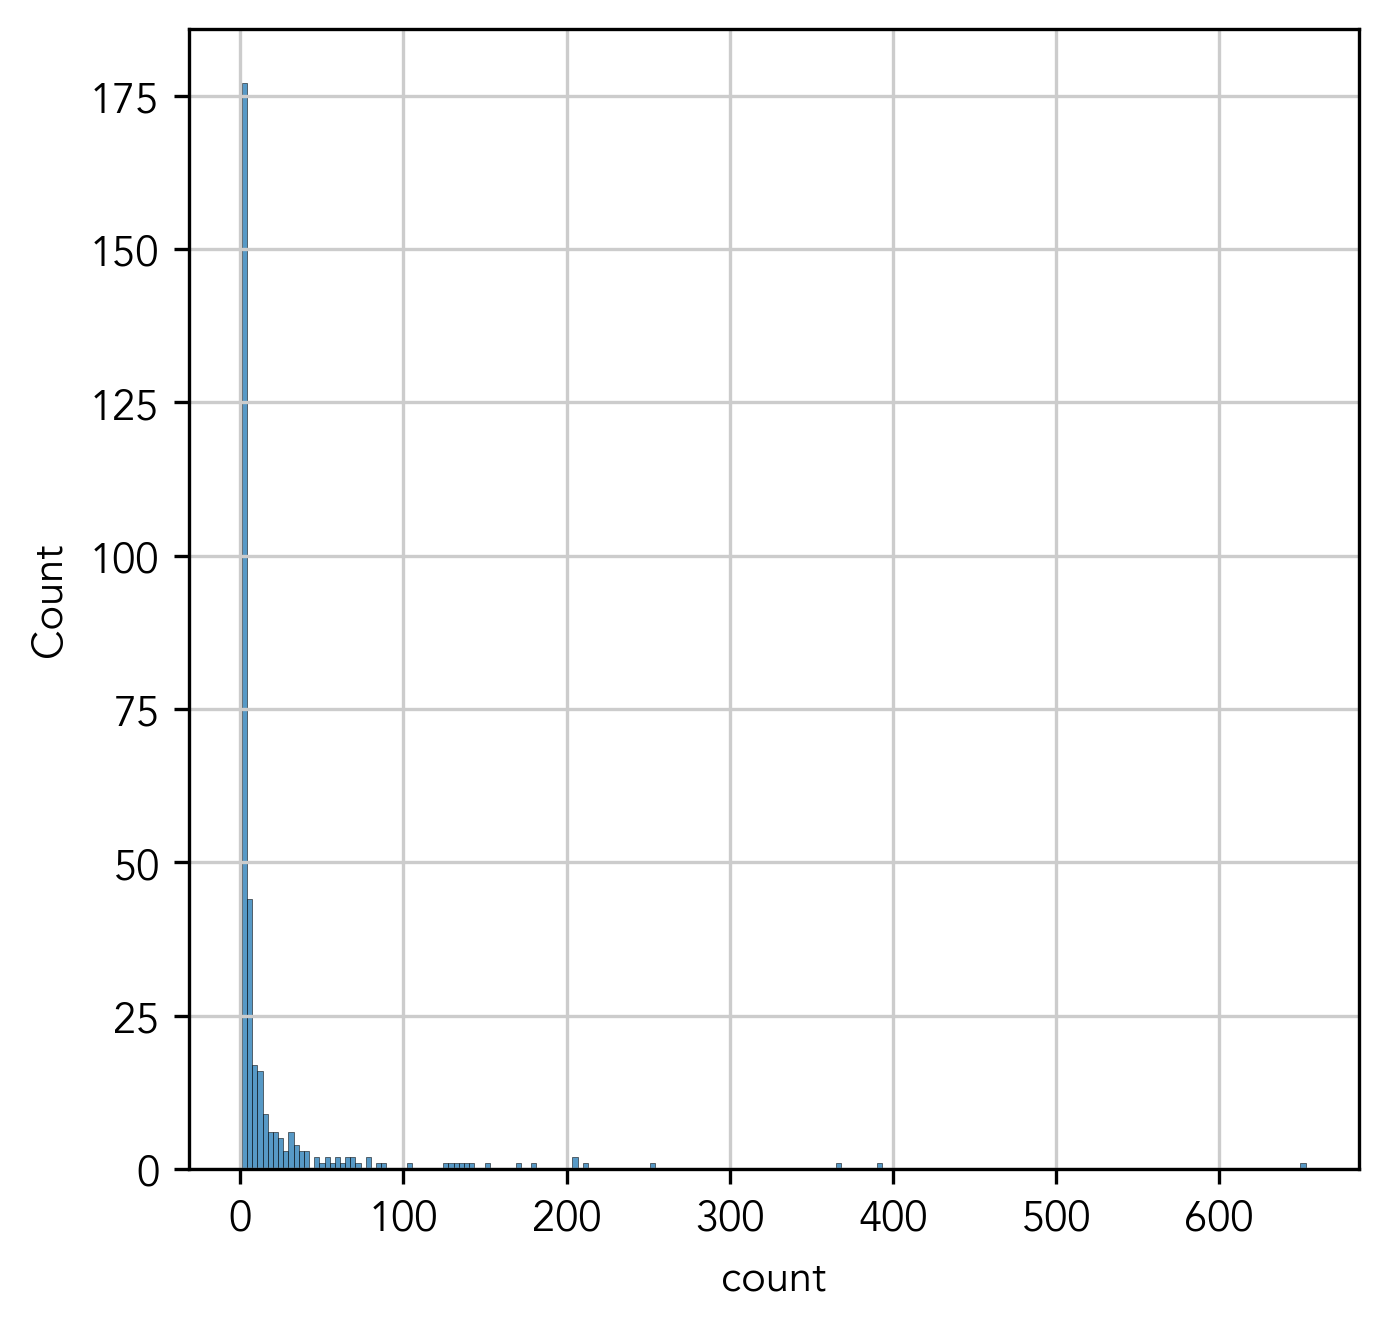

In [ ]:
sns.histplot(adata.obs['cluster_name'].value_counts())

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='louvain', method='wilcoxon')


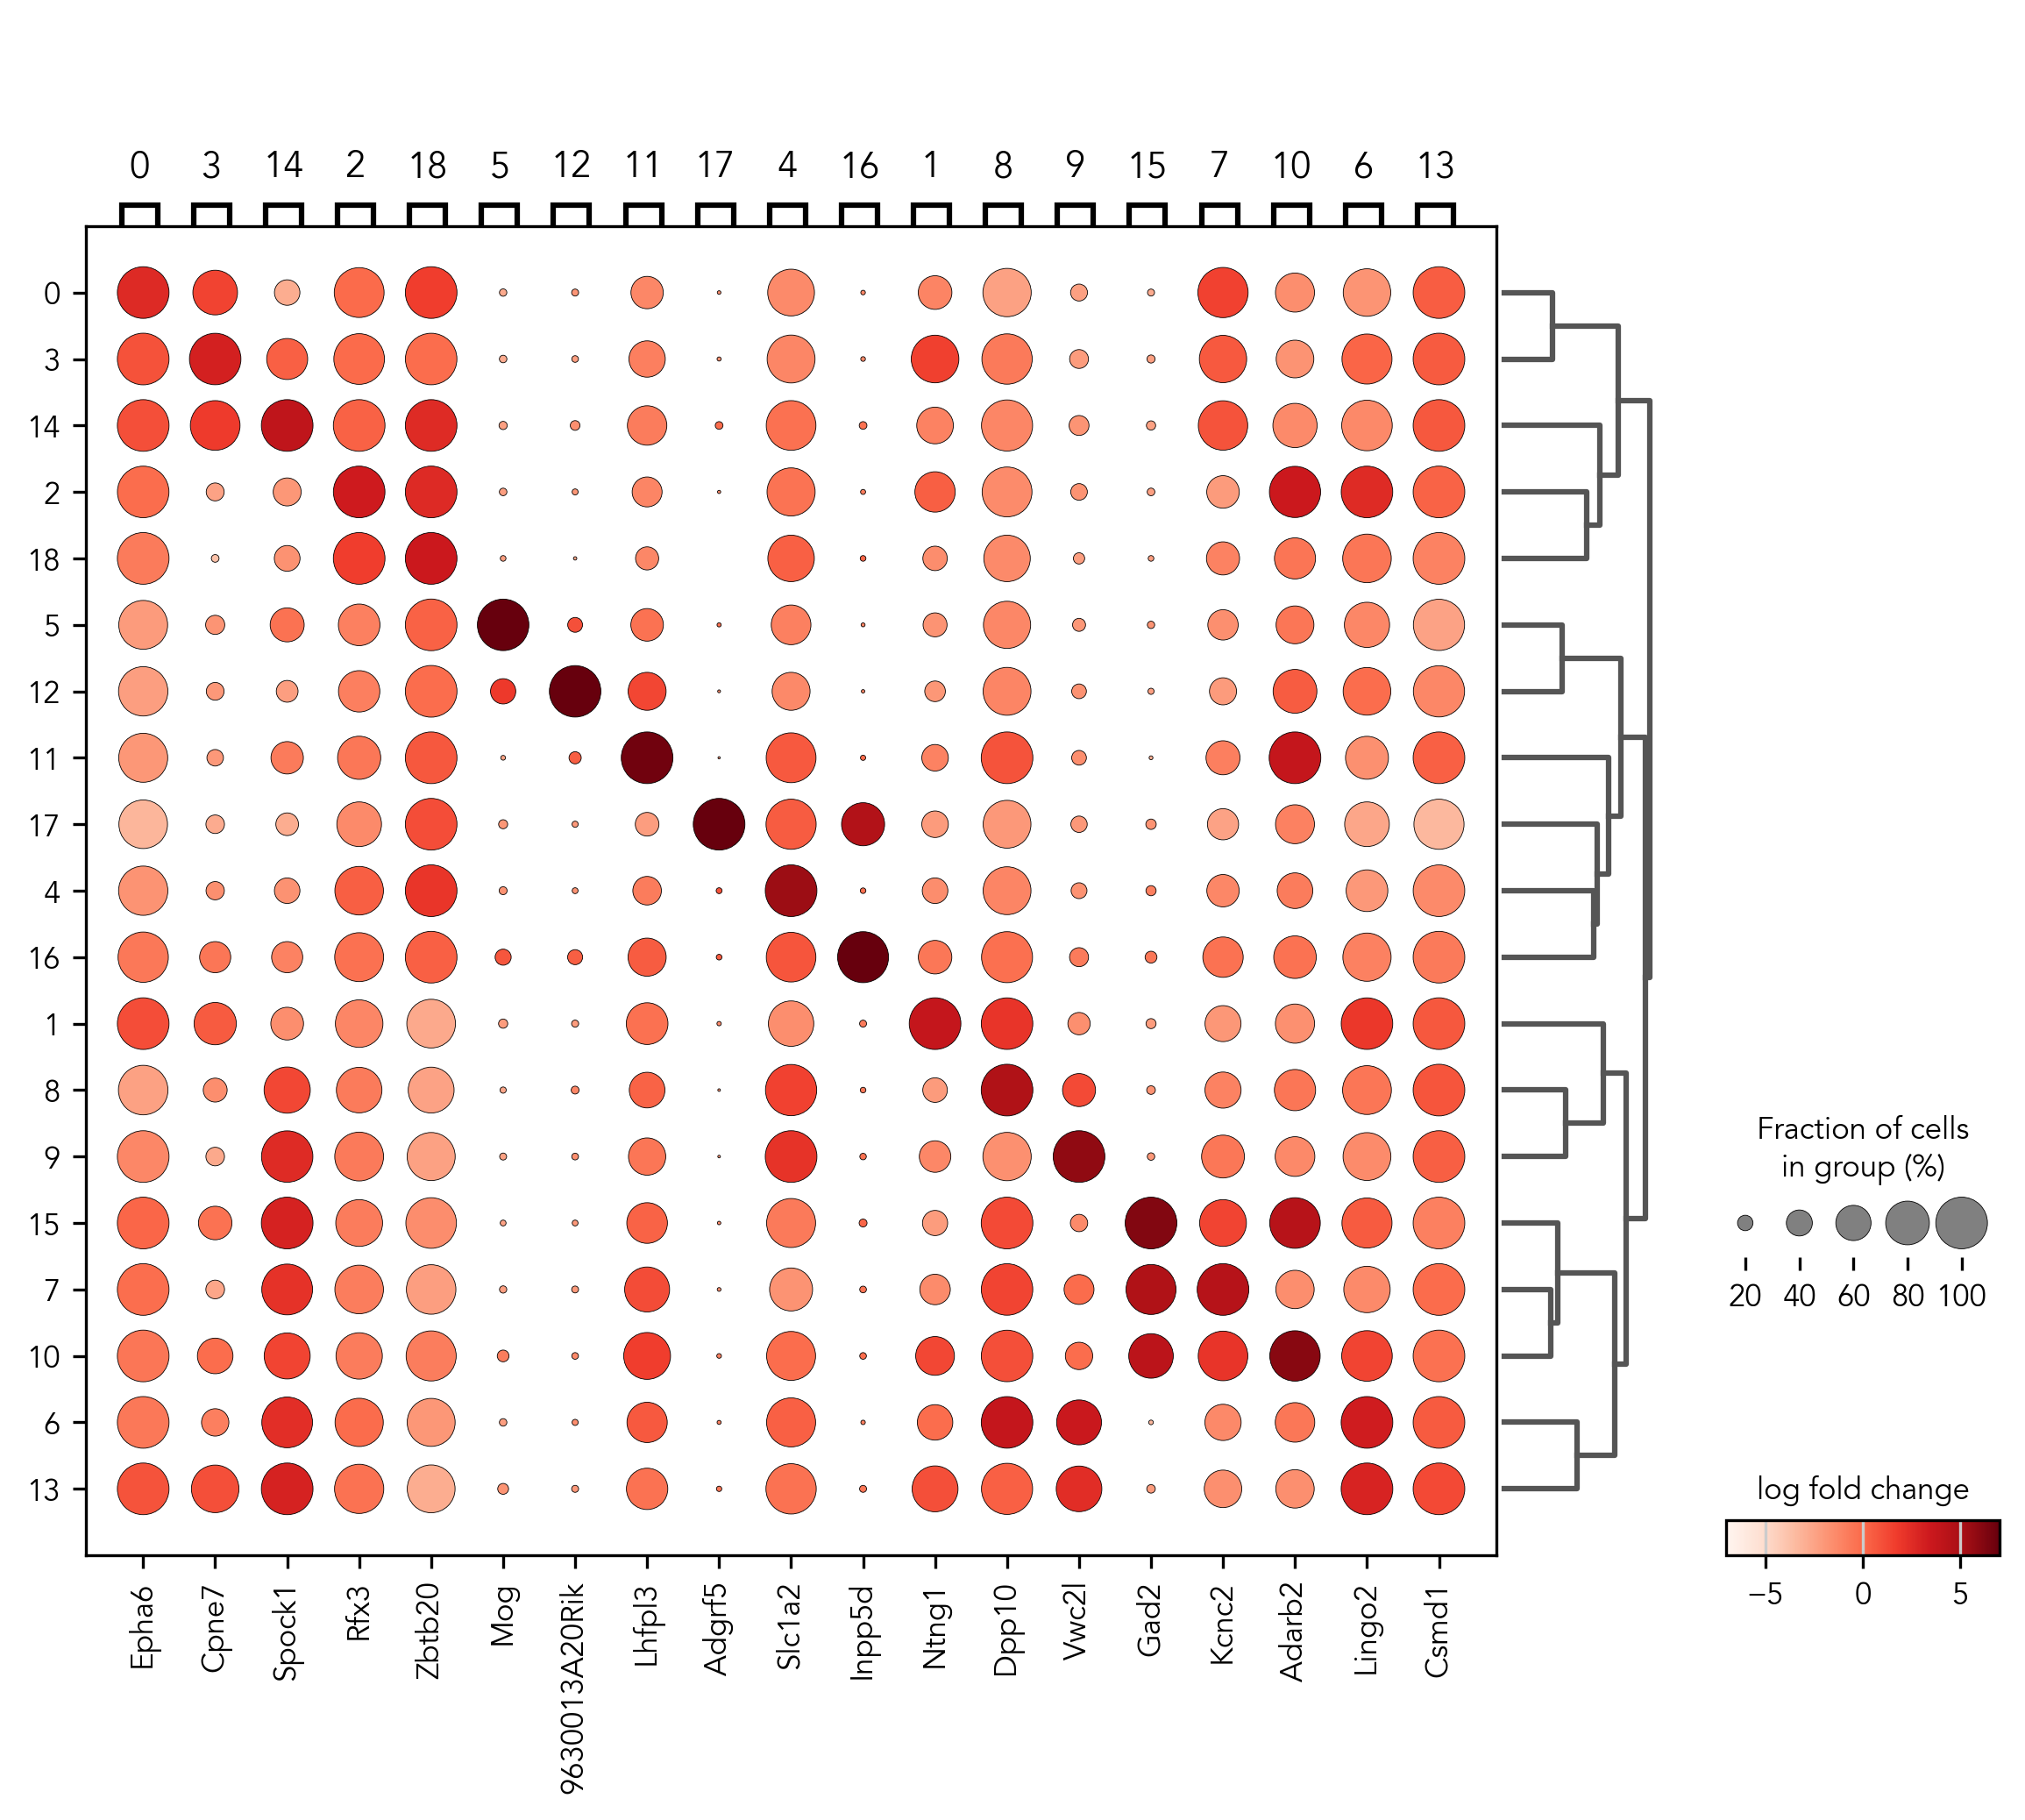

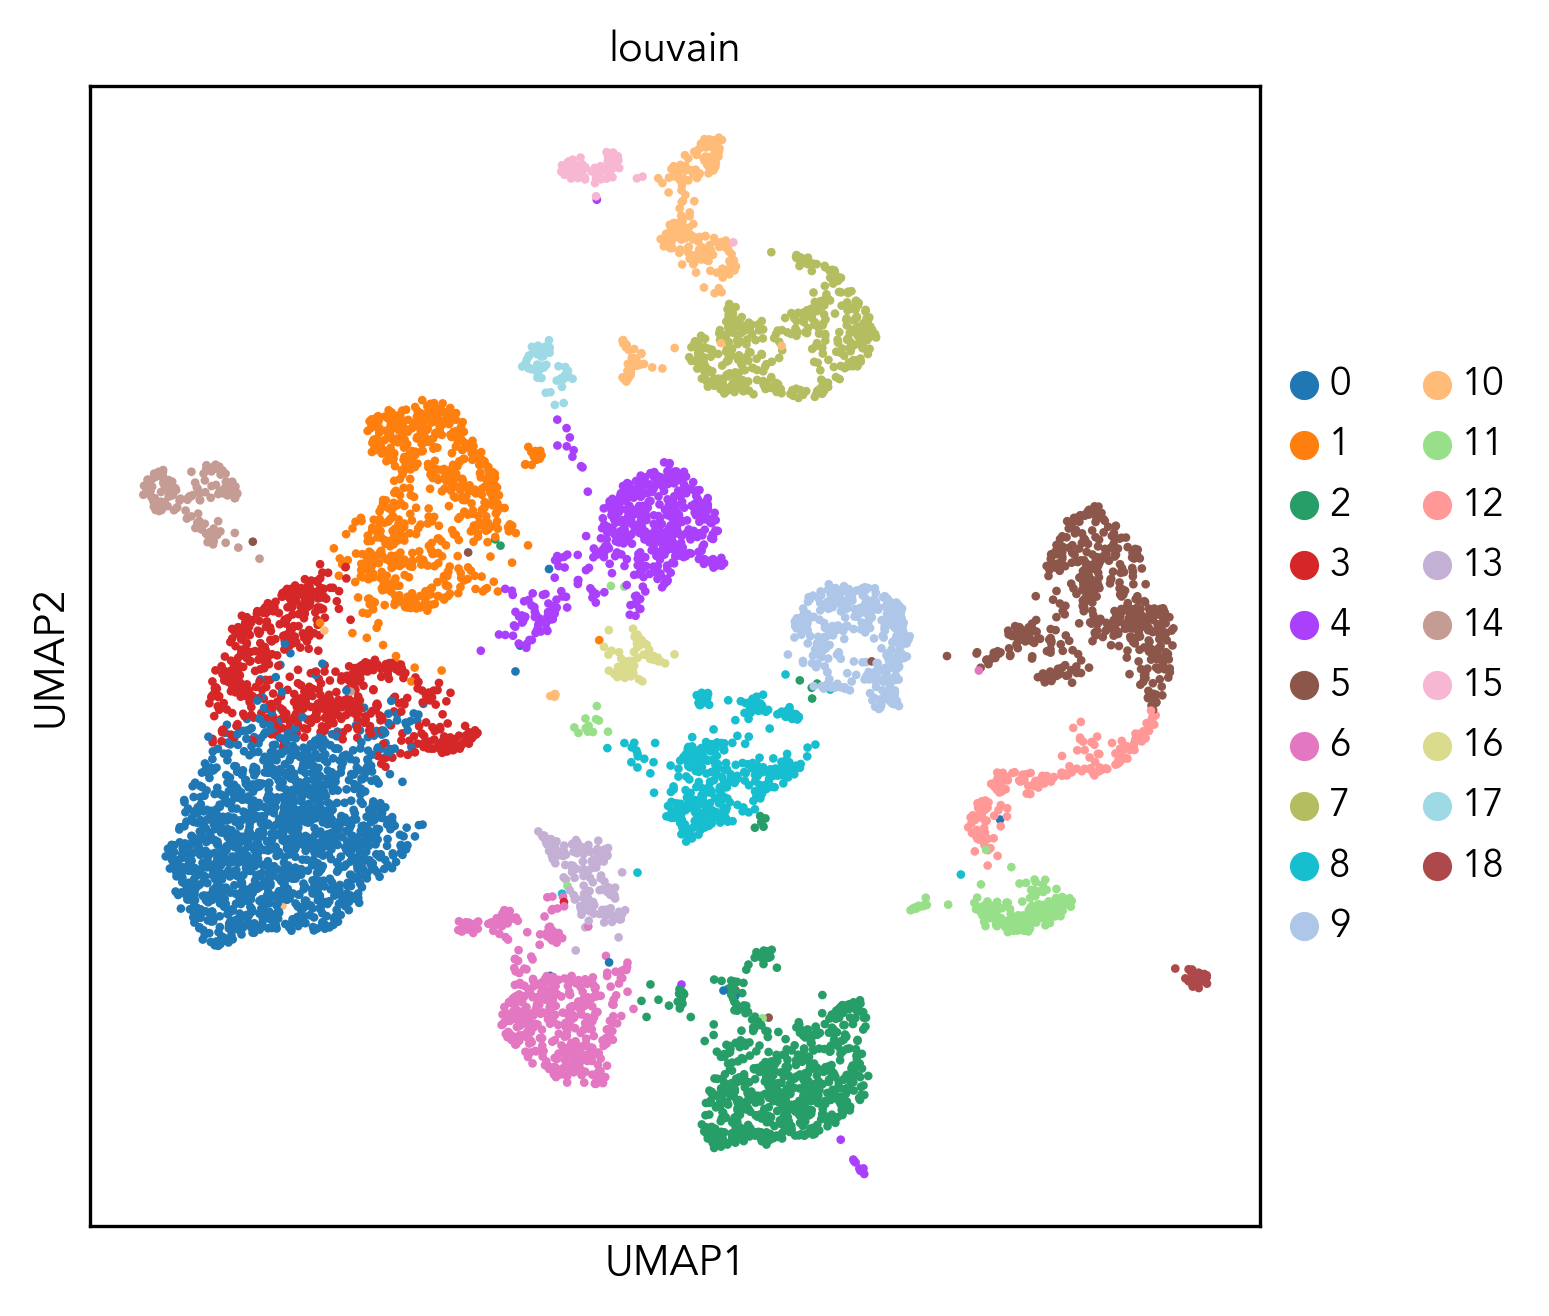

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=1, values_to_plot='logfoldchanges', vmin=-7, vmax=7)
sc.pl.umap(adata, color=['louvain'])